# Redes de base radial (RBF)

## Entorno de desarrollo

Este trabajo fue realizado en Google Colab utilizando la versión 3.13.15 de Python y las siguientes versiones de librerías externas:
* gdown 5.2.2
* numpy 2.1.3
* matplotlib 3.10.0
* scikit-learn 1.6.1

## Librerías

In [1]:
# Descargar librerías externas
!pip install numpy==2.1.3 matplotlib==3.10.0 scikit-learn==1.6.1 --quiet

In [2]:
# Importar librerías externas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import Image, display

## Contexto

Vamos a aproximar la función sen(x) con Redes de Base Radial (RBF). Simularemos que tenemos un dataset de pares (x,y), pero que no sabemos cuál es la función detrás de esos datos. Esos valores los sacaremos de la función sen(x), y les agregaremos un poco de ruido aleatorio.

## Estructura de la red

La red consistirá en una neurona de entrada, 8 neuronas en la capa oculta y 1 neurona de salida. En RBF, la capa de entrada pasa directamente los x como entrada para la capa oculta, no hay pesos entre esas dos capas.

En la capa oculta, la función de activación por defecto de las RBF es la función Gaussiana, definida como:

$$ \phi(x) = e^{ - \frac{\|x - \mu\|^2}{2\sigma^2} } $$

Pero como x tiene una sola dimensión:

$$ \phi(x) = e^{ - \frac{(x - \mu)^2}{2\sigma^2} } $$

Donde:
* $\mu$ es el centro de la neurona
* $\sigma$ es el rango de influencia de la función Gaussiana

Básicamente, funciona así: Nos fijamos qué tan lejos está el dato x del centro de la neurona $\mu$ y qué tanta dispersión tiene esa función Gaussiana. Entonces:
* A mayor dispersión y más cerca de $\mu$, mayor valor devolverá la función.
* A menor dispersión y más lejos de $\mu$, menor valor devolverá la función.
Ejecutándo el siguiente código se puede ver ilustrativamente a qué nos referimos con esto:

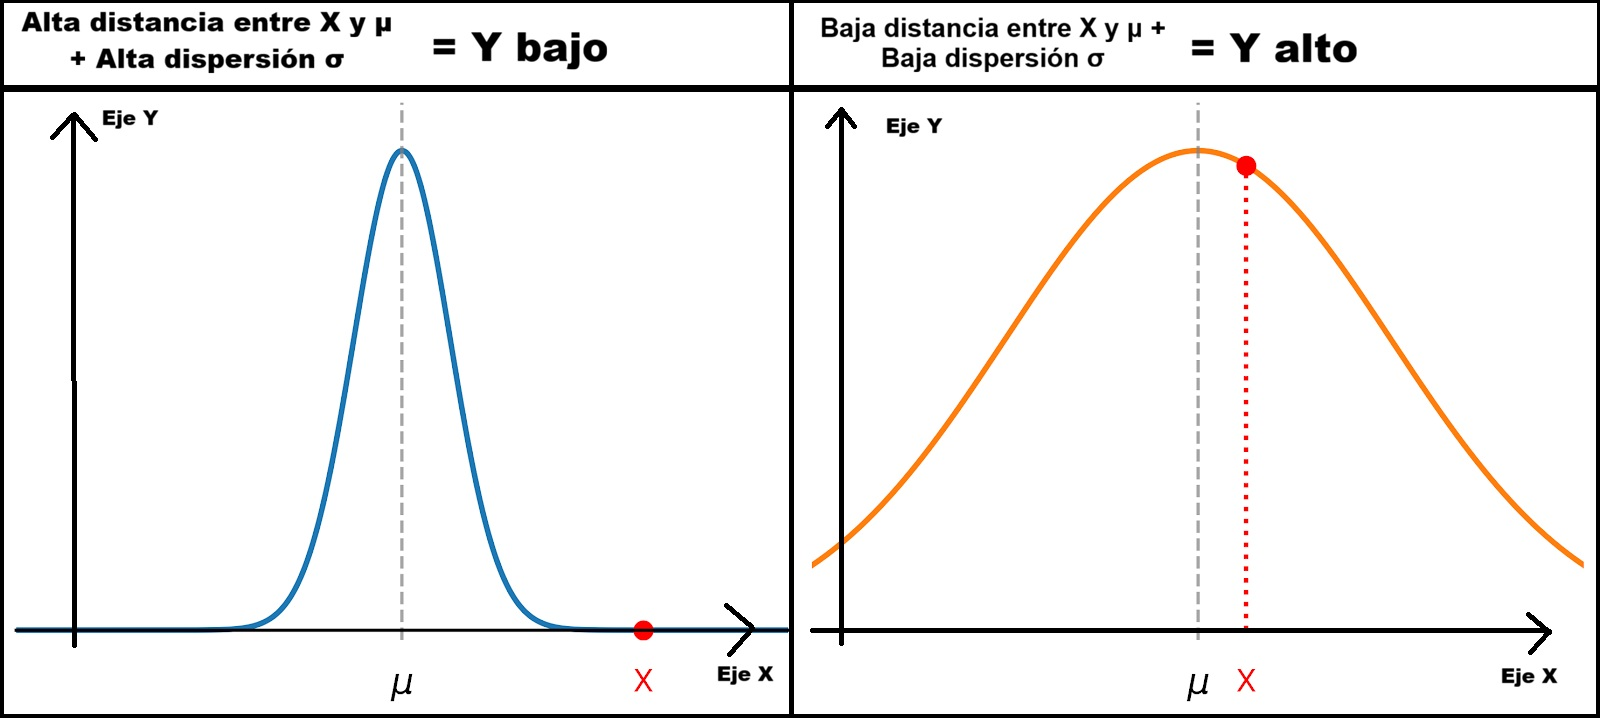

In [3]:
display(Image('ejemplo-rbf-funcion-gaussiana.jpg', width=1200))

Además, definimos una función Gaussiana en código:

In [4]:
def gaussiana(x, mu, sigma):
    return np.exp(-((x - mu) ** 2) / (2 * (sigma ** 2)))

Y luego de pasar por esa función de activación, se transmite esta salida multiplicada por los pesos a la neurona de salida. En las RBF, generalmente no hay función de activación en la capa de salida, y aquí tampoco aplicaremos.

## Generación de dataset

Como bien decíamos, el dataset serán valores (x,y) sacados de la función sen(x) pero con un poco de ruido. Creamos 300 de esos pares:

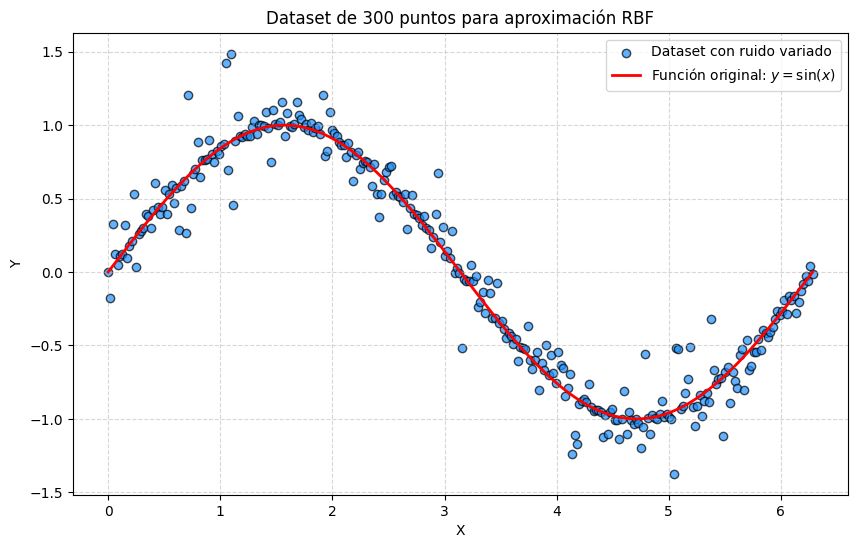

In [5]:
np.random.seed(42)                     # Reproducibilidad

x = np.linspace(0, 2 * np.pi, 300)     # Generamos 300 valores de X entre 0 y 2𝞹
y_real = np.sin(x)                     # Calculamos el seno de esos 300 valores

# Introducir ruido a los datos
escalas_ruido = np.random.exponential(scale=0.1, size=300)
ruido = np.random.normal(loc=0, scale=escalas_ruido, size=300)   #
y = y_real + ruido

# Visualizamos cómo quedaron los puntos VS la función teórica
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='dodgerblue', alpha=0.7, edgecolors='k', label='Dataset con ruido variado')
plt.plot(x, y_real, color='red', linewidth=2, label=r'Función original: $y = \sin(x)$')
plt.title('Dataset de 300 puntos para aproximación RBF')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Inicialización de centros $\mu$ y desviaciones $\sigma$

Nosotros sabemos que al haber creado los datos sabemos que los X son equidistantes, ya que los creamos con np.linspace(). Pero en un dataset real, nunca vamos a saber si están distribuidos equitativamente, por lo que los centros $\mu$ los tendríamos que determinar con algún algoritmo. Lo estándar es utilizar k-means y ver en donde se ubicarían los 8 centros.

In [6]:
X_matrix = x.reshape(-1, 1)   # Pasamos x de vector a matriz columna para K-Means

# K-Means
K = 8                                                      # Buscamos 8 centros para las 8 neuronas
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)  # n_init=10 es para que pruebe 10 inicializaciones distintas y se quede con la mejor
kmeans.fit(X_matrix)
centros = kmeans.cluster_centers_.flatten()                # Extraemos los centros

Y para las desviaciones $\sigma$, una opción es utilizar la dispersión misma de los clusters formados en K-Means. Sin embargo, aquí utilizaremos el método del vecino más cercano, el cual define la dispersión de la función Gaussiana de una neurona en base a la distancia hasta el centro de su neurona más próxima

Con esta medida nos aseguramos de que las funciones Gaussianas se solapen en cierta medida y formen un puente continuo a lo largo de todo el eje X. Si llegamos a utilizar la definición formal de varianza como $\sigma$, esto podría no suceder y podría quedar un hueco por falta de muestras. Para este caso preciso, ambos métodos funcionarían

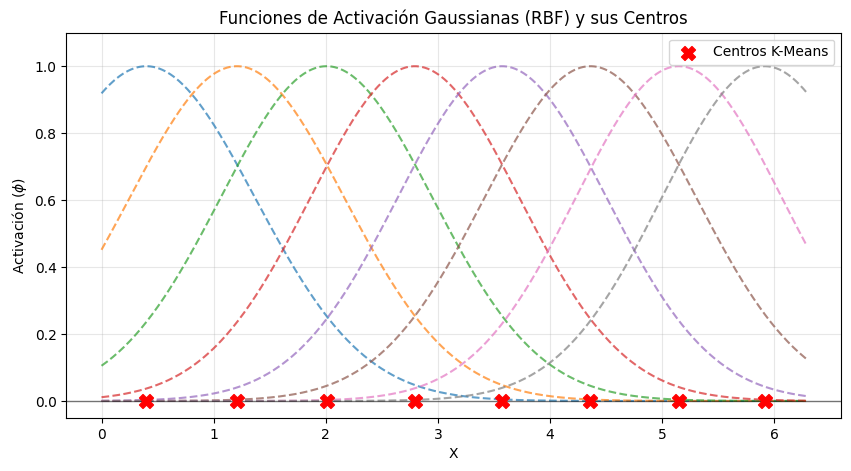

In [7]:
centros.sort()  # Ordenamos los centros

# 4. Calculamos un sigma INDIVIDUAL para cada centro (Vecino más cercano)
sigmas = np.zeros(K)       # Inicializamos los σ en 0
factor_solapamiento = 1.2  # Multiplicador para asegurar que las campanas se solapen bien

for i in range(K):
    distancias = np.abs(centros - centros[i])
    distancias_validas = distancias[distancias > 0]    # Filtramos la distancia de un centro a sí mismo
    distancia_vecino = np.min(distancias_validas)      # El vecino más cercano es la menor de esas distancias
    sigmas[i] = distancia_vecino * factor_solapamiento # Asignamos el sigma individual con su factor de solapamiento

# Visualizamos los centros y cómo abarcan el espacio
plt.figure(figsize=(10, 5))
x_continuo = np.linspace(x.min(), x.max(), 500)

for i, (mu, s) in enumerate(zip(centros, sigmas)):
    y_gaussiana = gaussiana(x_continuo, mu, s)
    plt.plot(x_continuo, y_gaussiana, '--', alpha=0.7)

plt.scatter(centros, np.zeros_like(centros), color='red', s=100, marker='X', zorder=5, label='Centros K-Means')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)

plt.title('Funciones de Activación Gaussianas (RBF) y sus Centros')
plt.xlabel('X')
plt.ylabel(r'Activación ($\phi$)')
plt.ylim(-0.05, 1.1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## Ajuste de pesos W

Ahora tenemos que ajustar los pesos W entre la capa oculta y la capa de salida. Para ello, utilizaremos el método analítico que calcula todos los pesos óptimos en una sola iteración, para la cuál utiliza la fórmula:

$$W = H^+ \cdot Y$$

Siendo:
* Y la matriz de salidas deseadas (en este caso, como solo hay una salida deseada por dato, es una matriz columna)
* $H$ la matriz de activaciones de la capa oculta para cada dato X (son 8 activaciones por cada dato)
* $H^+$ la pseudoinversa de Moore-Penrose de H.
* W la matriz de pesos $w_{ij}$ (como solo hay una neurona de salida, j=1 siempre lo que vuelve a W una matriz columna)

Matricialmente nuestro caso se vería así:

$$
\begin{bmatrix}
w_1 \\
w_2 \\
\vdots \\
w_8
\end{bmatrix}_{(8 \times 1)} =
\begin{bmatrix}
h_{1,1} & h_{1,2} & \dots & h_{1,8} \\
h_{2,1} & h_{2,2} & \dots & h_{2,8} \\
\vdots & \vdots & \ddots & \vdots \\
h_{N,1} & h_{300,2} & \dots & h_{300,8}
\end{bmatrix}_{(300 \times 8)}^{+}
\cdot
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_{300}
\end{bmatrix}_{(300 \times 1)}
$$

In [8]:
# Construcción de H
N = len(x)
K = len(centros)
H = np.zeros((N, K))
for j in range(K):
    H[:, j] = gaussiana(x, centros[j], sigmas[j])

H_pinv = np.linalg.pinv(H)     # Pseudoinversa de H
W = H_pinv @ y.reshape(-1, 1)  # W=H+*Y

## Evaluación de la red

Con los pesos ya configurados, vamos a ver cómo es la función de la red RBF formada. Evaluaremos los resultados para 500 datos equidistantes ubicados en el rango de los datos originales X, para que la función se vea lo más suave posible. Compararemos la ubicación de los datos, la función real (sen(x)) y la función que devuelve la red.

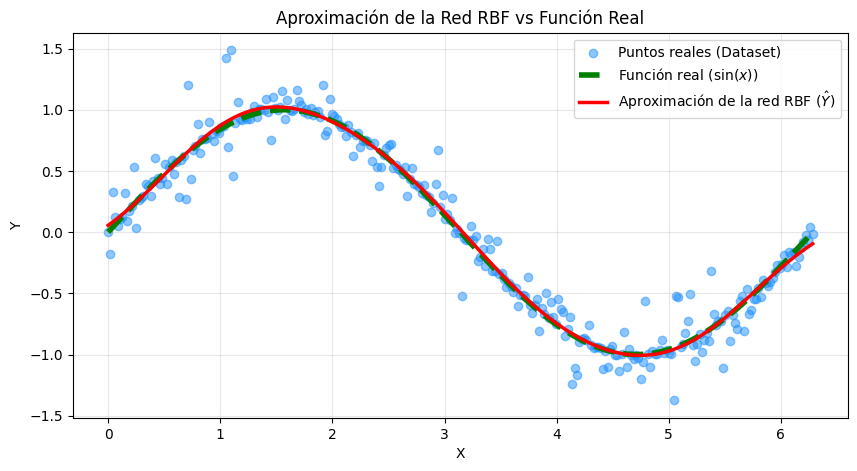

In [9]:
# Construcción de las 500 activaciones H para la curva continua
x_continuo = np.linspace(x.min(), x.max(), 500)
H_continuo = np.zeros((len(x_continuo), K))
for j in range(K):
    H_continuo[:, j] = gaussiana(x_continuo, centros[j], sigmas[j])

y_pred = H_continuo @ W   # Multiplicamos H por W obteniendo los puntos de ejemplo para formar la curva de la red

# Visualización de puntos X, función real y función de la red
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='dodgerblue', alpha=0.5, label='Puntos reales (Dataset)')                                        # Puntos reales (con ruido)
plt.plot(x_continuo, np.sin(x_continuo), color='green', linestyle='--', linewidth=4, label=r'Función real ($\sin(x)$)')  # Función real (seno puro)
plt.plot(x_continuo, y_pred, color='red', linewidth=2.5, label=r'Aproximación de la red RBF ($\hat{Y}$)')                # Función de aproximación de la red

plt.title('Aproximación de la Red RBF vs Función Real')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

La función que devuelve la red es prácticamente la misma a la función real.

## Créditos

* Imágen de la función Gaussiana: Generada por el mismo autor mediante Gemini.
